<a href="https://colab.research.google.com/github/bhavananamburi/oasis-infobyte-internship-/blob/main/Bhavana_task1_Exploratory_Data_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Loading the Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import  warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset.csv


In [ ]:
df = pd.read_csv('retail_sales_dataset.csv')

In [ ]:
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:
df.nunique()

,0
Transaction ID,1000
Date,345
Customer ID,1000
Gender,2
Age,47
Product Category,3
Quantity,4
Price per Unit,5
Total Amount,18


In [ ]:
df.shape

(1000, 9)

In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [ ]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [ ]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# **Descriptive Statistics**

In [ ]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


**Mean**

In [ ]:
print(df[['Age','Quantity','Price per Unit','Total Amount']].mean())

Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64


**Median**

In [ ]:
print(df[['Age','Quantity','Price per Unit','Total Amount']].median())

Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64


**Mode**

In [ ]:
print(df[['Age','Quantity','Price per Unit','Total Amount']].mode())

   Age  Quantity  Price per Unit  Total Amount
0   43       4.0            50.0          50.0
1   64       NaN             NaN           NaN


**Standard Deviation**

In [ ]:
print(df[['Age','Quantity','Price per Unit','Total Amount']].std())

Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


# **Time Series Analysis**

**Monthly Sales Trend**

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

monthly_sales = df.groupby(
    df['Date'].dt.to_period('M')
)['Total Amount'].sum()

monthly_sales.index = monthly_sales.index.astype(str)

monthly_sales_df = monthly_sales.reset_index()
monthly_sales_df.columns = ['Month', 'Total Sales']

monthly_sales_df

,Month,Total Sales
0,2023-01,35450
1,2023-02,44060
2,2023-03,28990
3,2023-04,33870
4,2023-05,53150
5,2023-06,36715
6,2023-07,35465
7,2023-08,36960
8,2023-09,23620
9,2023-10,46580


**Line Plot**

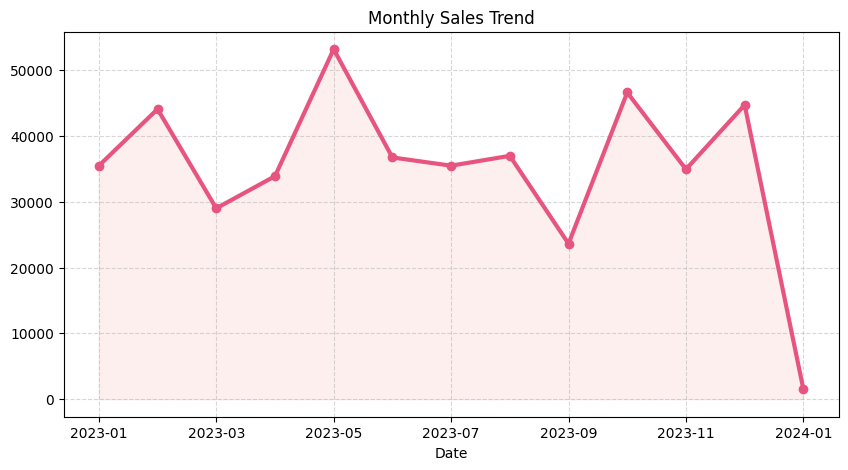

In [ ]:
plt.figure(figsize=(10,5))

monthly_sales.plot(
    kind='line',
    marker='o',
    linewidth=3,
    color='#e75480'
)

plt.fill_between(
    monthly_sales.index,
    monthly_sales.values,
    alpha=0.3,
    color='#fbcbc9'
)

plt.title("Monthly Sales Trend")
plt.grid(ls='--', alpha=0.5)

plt.show()

# **Customer Analysis**

**Gender-wise Sales analysis**

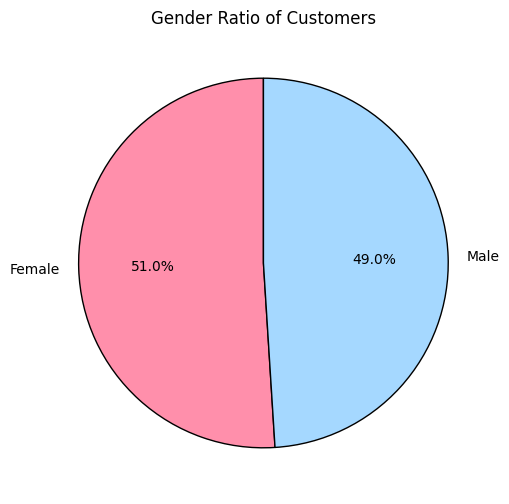

In [ ]:
gender_count = df['Gender'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_count,
    labels=gender_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff8fab', '#a5d8ff'],             # Boy = Pink, Girl = Blue
    wedgeprops={'edgecolor':'black'}
)

plt.title("Gender Ratio of Customers")

plt.show()

Gender-wise sales analysis

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


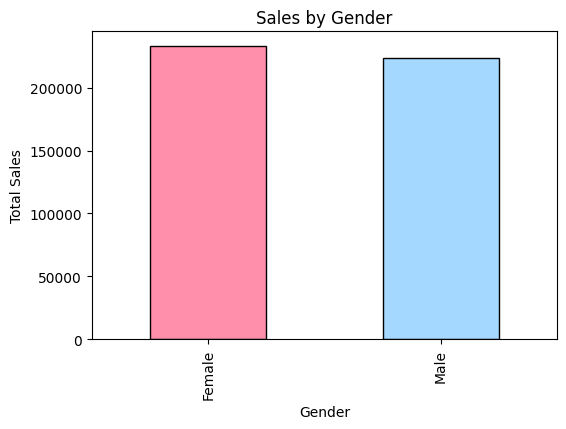

In [ ]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()
print(gender_sales
)


plt.figure(figsize=(6,4))

gender_sales.plot(
    kind='bar',
    color=['#ff8fab', '#a5d8ff'],
    edgecolor='black'
)

plt.title("Sales by Gender")
plt.ylabel("Total Sales")
plt.show()

# **Product Analysis**

**Category-wise Sales**

In [ ]:
category_sales = df.groupby(
    'Product Category'
)['Total Amount'].sum()

print(category_sales)

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


**Bar Chart**(**Category-wise Sales**)

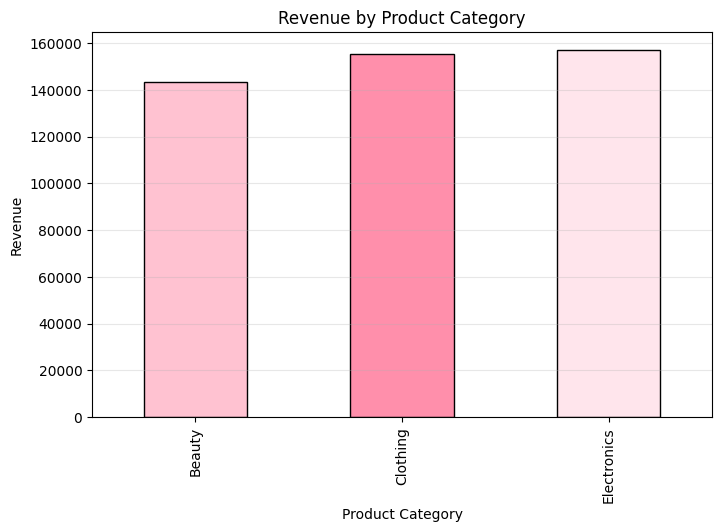

In [ ]:
plt.figure(figsize=(8,5))

category_sales.plot(
    kind='bar',
    color=['#ffc2d1', '#ff8fab', '#ffe5ec'],
    edgecolor='black'
)

plt.title("Revenue by Product Category")
plt.ylabel("Revenue")
plt.grid(axis='y', alpha=0.3)

plt.show()

**Quantity Sold by Category**

In [ ]:
quantity_category = df.groupby(
    'Product Category'
)['Quantity'].sum()

print(quantity_category)

Product Category
Beauty         771
Clothing       894
Electronics    849
Name: Quantity, dtype: int64


**Bar Chart**(**Quantity Sold by product Category**)

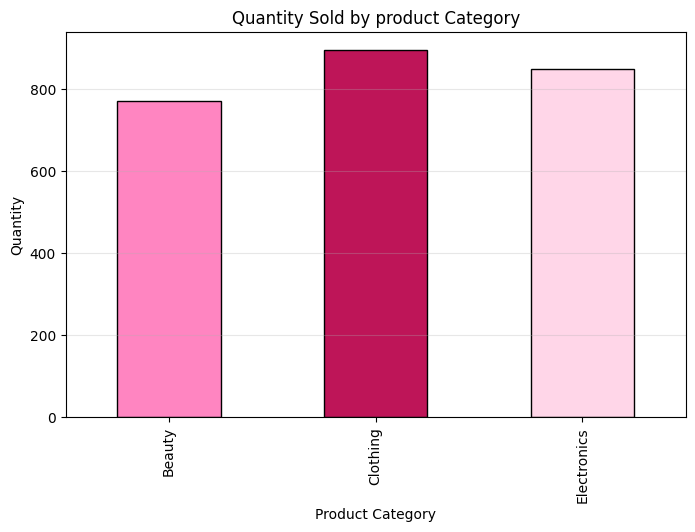

In [ ]:
plt.figure(figsize=(8,5))

quantity_category.plot(
    kind='bar',
    color=['#ff85c1', '#be1558', '#ffd6e8'],
    edgecolor='black'
)

plt.title("Quantity Sold by product Category")
plt.ylabel("Quantity")
plt.grid(axis='y', alpha=0.3)

plt.show()

# **Heatmap Analysis**

**Correlation Matrix**

In [ ]:
corr = df[['Age',
           'Quantity',
           'Price per Unit',
           'Total Amount']].corr()

print(corr)

                     Age  Quantity  Price per Unit  Total Amount
Age             1.000000 -0.023737       -0.038423     -0.060568
Quantity       -0.023737  1.000000        0.017501      0.373707
Price per Unit -0.038423  0.017501        1.000000      0.851925
Total Amount   -0.060568  0.373707        0.851925      1.000000


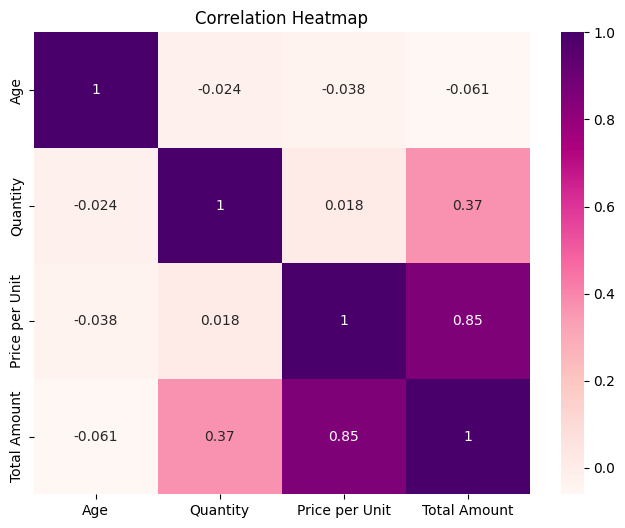

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='RdPu'
)

plt.title("Correlation Heatmap")
plt.show()

# **Customer spending** analysis


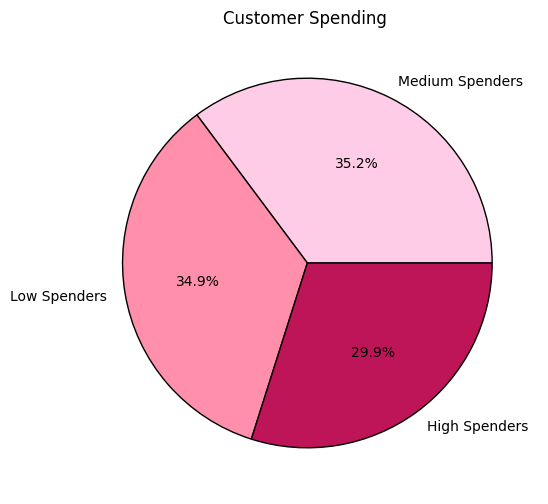

In [ ]:
customer_spending = df.groupby('Customer ID')['Total Amount'].sum()

customer_spending = pd.qcut(
    customer_spending,
    q=3,
    labels=['Low Spenders', 'Medium Spenders', 'High Spenders']
)

customer_spending.value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#ffcce7', '#ff8fab', '#be1558'],
    wedgeprops={'edgecolor':'black'},
    figsize=(6,6)
)

plt.title("Customer Spending ")
plt.ylabel('')
plt.show()

**Total Spending by Age Group**

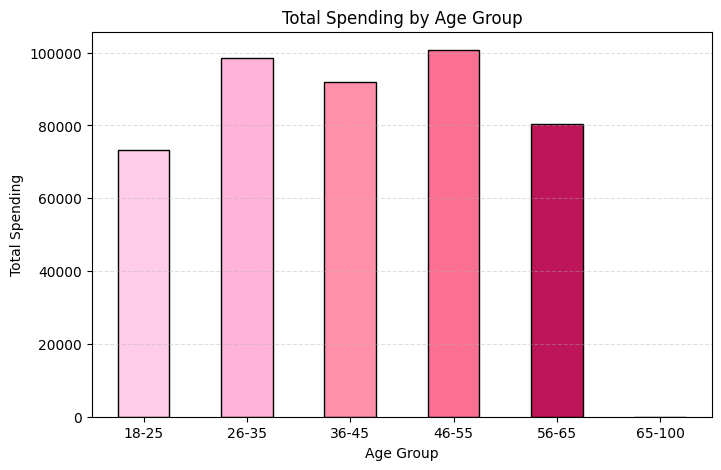

In [ ]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[18, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65','65-100']
)


age_group_spending = df.groupby('Age Group')['Total Amount'].sum()

plt.figure(figsize=(8,5))

age_group_spending.plot(
    kind='bar',
    color=['#ffcce7', '#ffb3d9', '#ff8fab', '#fb6f92', '#be1558'],
    edgecolor='black'
)

plt.title("Total Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Spending")

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

**Top Spending Customers**

In [ ]:
top_customers = df.groupby(
    'Customer ID'
)['Total Amount'].sum().sort_values(
    ascending=False
).head(10)

print(top_customers)

Customer ID
CUST015    2000
CUST412    2000
CUST970    2000
CUST547    2000
CUST281    2000
CUST416    2000
CUST420    2000
CUST927    2000
CUST447    2000
CUST342    2000
Name: Total Amount, dtype: int64


**Top 10 Customers**

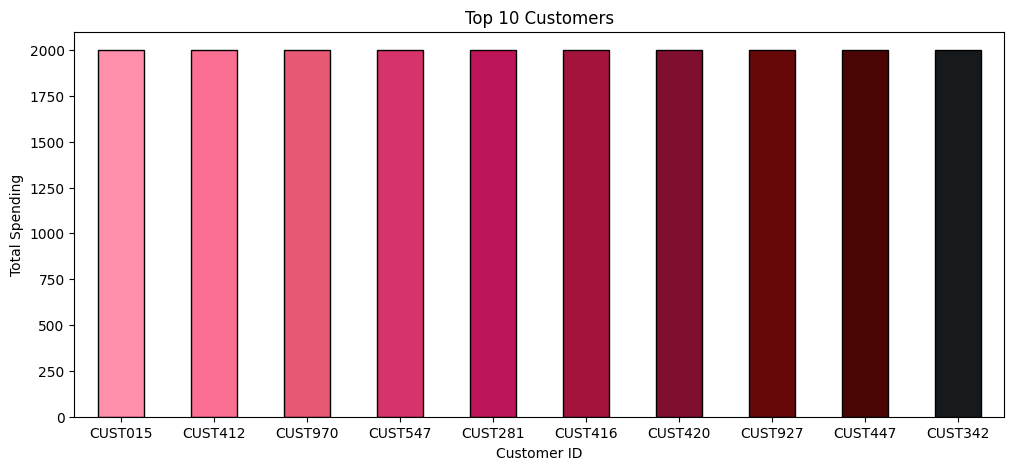

In [ ]:
plt.figure(figsize=(12,5))

top_customers.plot(
    kind='bar',
    color=['#ff8fab','#fb6f92','#e75874','#d6336c',
       '#be1558','#a4133c','#800f2f','#660708',
       '#4a0404','#161a1d'],
    edgecolor='black'
)

plt.title("Top 10 Customers")
plt.ylabel("Total Spending")
plt.xticks(rotation=0)
plt.show()

# **Retail Sales Dashboard**

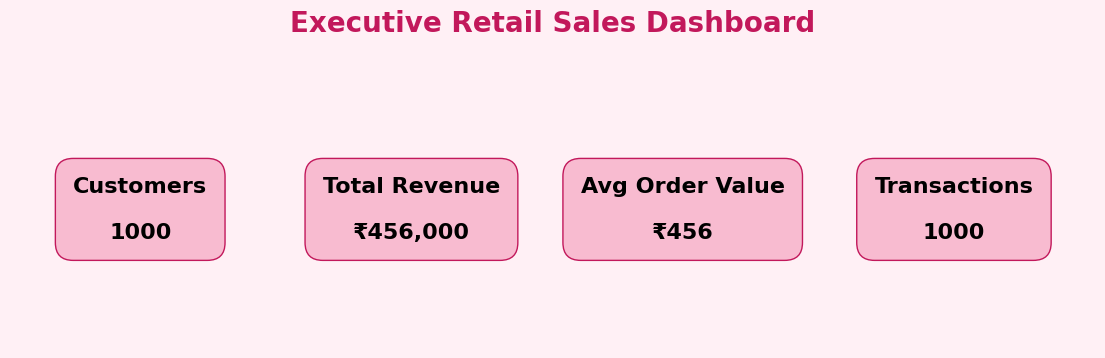

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14,4))
ax.axis('off')
fig.patch.set_facecolor('#FFF0F5')

plt.title(
    "Executive Retail Sales Dashboard",
    fontsize=20,
    fontweight='bold',
    color='#C2185B'
)

cards = [
    ("Customers", df['Customer ID'].nunique()),
    ("Total Revenue", f"₹{df['Total Amount'].sum():,.0f}"),
    ("Avg Order Value", f"₹{df['Total Amount'].mean():.0f}"),
    ("Transactions", len(df))
]

for x, (label, value) in zip([0.12, 0.37, 0.62, 0.87], cards):
    ax.text(
        x, 0.45,
        f"{label}\n\n{value}",
        ha='center',
        va='center',
        fontsize=16,
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.8',
            facecolor='#F8BBD0',
            edgecolor='#C2185B'
        )
    )

plt.show()

# Recommendations

* Focus on the highest-selling product categories by maintaining sufficient inventory and expanding product offerings.
* Offer discounts and promotional campaigns during months with lower sales to increase customer purchases.
* Introduce loyalty programs and personalized offers to retain top-spending customers and encourage repeat purchases.
* Target marketing efforts toward the age groups and customer segments that contribute the most to total sales.
* Use monthly sales trends and customer insights to improve inventory management and make data-driven business decisions.
